Setup complete ✅
Dataset shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


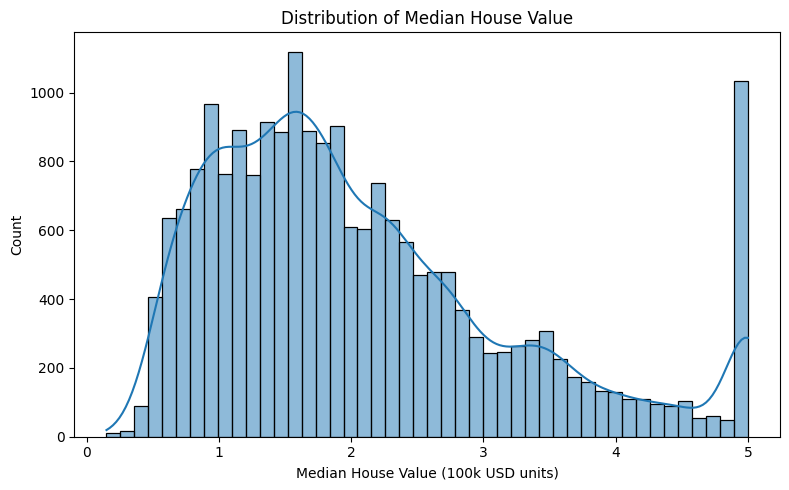

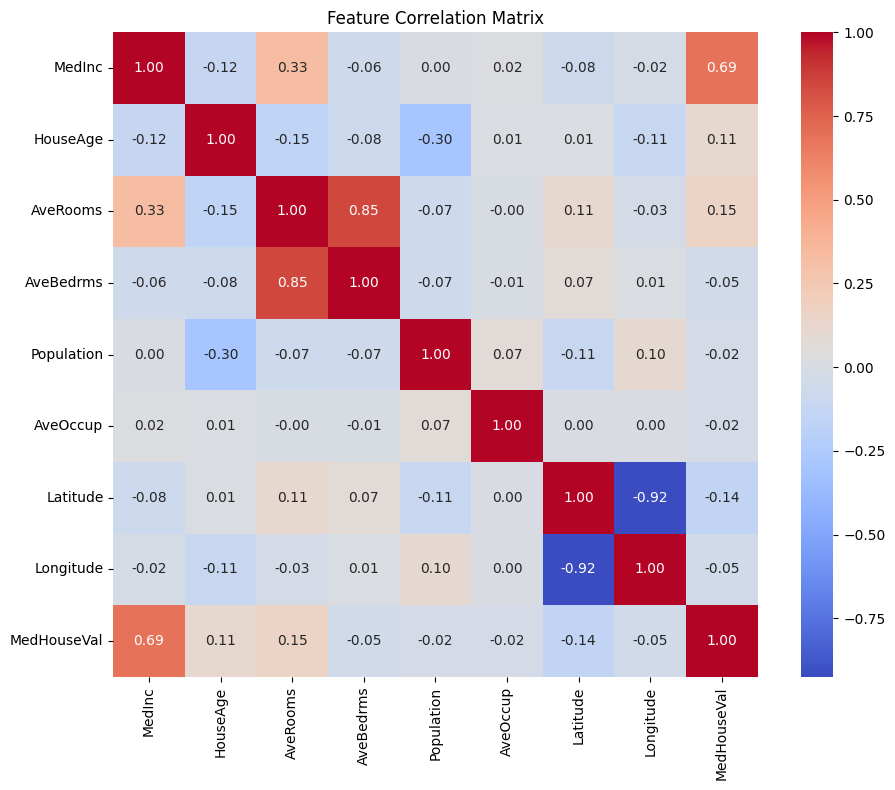

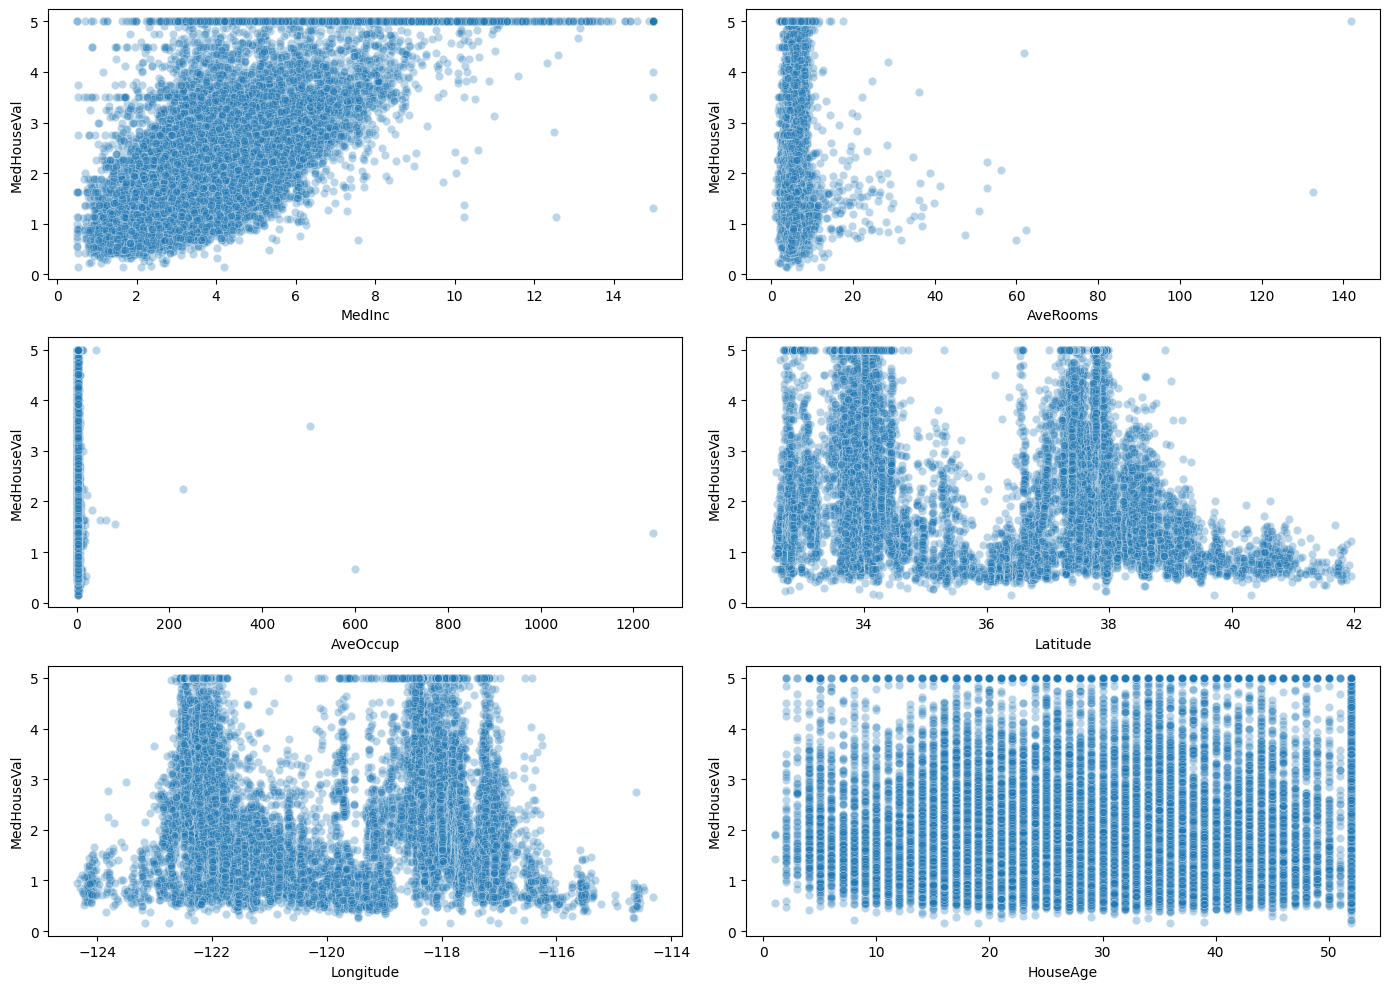

Train shape: (16512, 10) Test shape: (4128, 10)
--- Linear Regression ---
MAE:  0.4977
RMSE: 0.6867
R2:   0.6402


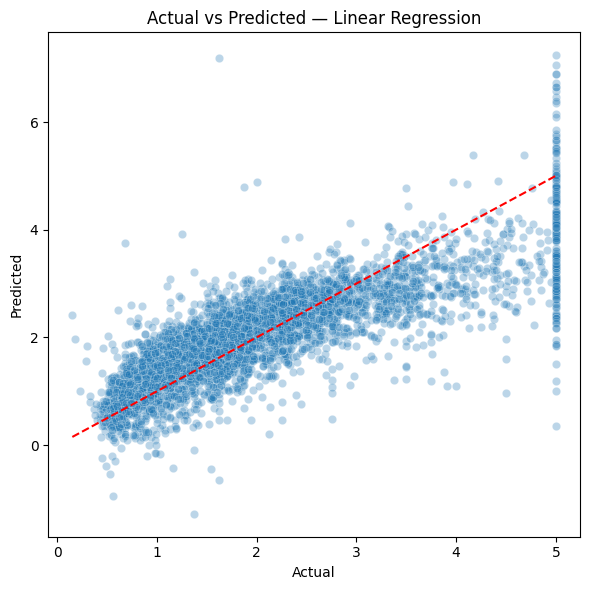

--- Random Forest ---
MAE:  0.3293
RMSE: 0.5059
R2:   0.8047


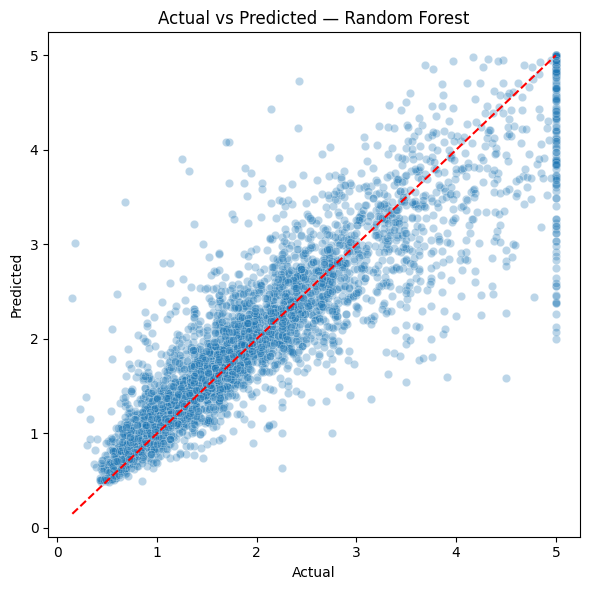

XGBoost not available; skipped.
Fitting 3 folds for each of 25 candidates, totalling 75 fits


In [ ]:
# %% [markdown]
# # House Price Prediction — Full Corrected Notebook
# 
# This notebook includes:
# - California Housing dataset loading
# - EDA with graphs
# - Feature engineering
# - Linear Regression, Random Forest, XGBoost (optional)
# - Model evaluation, comparison, and hyperparameter tuning
# - Save best model and scaler
# - Prediction helper function

# %% [markdown]
# ## 0. Setup

# %%
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt
import joblib
import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10,6)

# Sklearn imports
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reproducibility
RSEED = 42
np.random.seed(RSEED)

# Create folders for outputs
os.makedirs("results/figures", exist_ok=True)
os.makedirs("models", exist_ok=True)

print("Setup complete ✅")

# %% [markdown]
# ## 1. Load Dataset

# %%
cal = fetch_california_housing(as_frame=True)
df = cal.frame.copy()
df.head()

# %%
print("Dataset shape:", df.shape)
print("Features:", df.columns.tolist())

# %% [markdown]
# ## 2. Exploratory Data Analysis (EDA)

# %%
# Price distribution
plt.figure(figsize=(8,5))
sns.histplot(df["MedHouseVal"], kde=True)
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value (100k USD units)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("results/figures/price_distribution.png")
plt.show()

# %%
# Correlation heatmap
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("results/figures/correlation_matrix.png")
plt.show()

# %%
# Scatter plots
features_to_plot = ["MedInc", "AveRooms", "AveOccup", "Latitude", "Longitude", "HouseAge"]
plt.figure(figsize=(14,10))
for i, feat in enumerate(features_to_plot,1):
    plt.subplot(3,2,i)
    sns.scatterplot(x=df[feat], y=df["MedHouseVal"], alpha=0.3)
    plt.xlabel(feat)
    plt.ylabel("MedHouseVal")
plt.tight_layout()
plt.savefig("results/figures/feature_scatter_grid.png")
plt.show()

# %% [markdown]
# ## 3. Feature Engineering & Preprocessing

# %%
df_fe = df.copy()
df_fe["RoomsPerHousehold"] = df_fe["AveRooms"] / (df_fe["AveOccup"] + 1e-6)
df_fe["PopulationPerHousehold"] = df_fe["Population"] / (df_fe["AveOccup"] + 1e-6)

# Train-test split
X = df_fe.drop(columns=["MedHouseVal"])
y = df_fe["MedHouseVal"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RSEED)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# %%
# Scale features
numeric_cols = X_train.columns.tolist()
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=numeric_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=numeric_cols, index=X_test.index)

# Save scaler
joblib.dump(scaler, "models/scaler.pkl")

# %% [markdown]
# ## 4. Model Evaluation Function (fixed)

# %%
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, show_plots=True):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    # Fix for old sklearn versions
    try:
        rmse = mean_squared_error(y_te, preds, squared=False)
    except TypeError:
        rmse = sqrt(mean_squared_error(y_te, preds))
    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)
    print(f"--- {name} ---")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}")
    if show_plots:
        plt.figure(figsize=(6,6))
        sns.scatterplot(x=y_te, y=preds, alpha=0.3)
        plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--')
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title(f"Actual vs Predicted — {name}")
        plt.tight_layout()
        fname = f"results/figures/actual_vs_pred_{name.replace(' ','_')}.png"
        plt.savefig(fname)
        plt.show()
    return {"name": name, "mae": mae, "rmse": rmse, "r2": r2, "model": model}

# %% [markdown]
# ## 5. Train Models

# %%
# Linear Regression
lr = LinearRegression()
res_lr = evaluate_model("Linear Regression", lr, X_train_scaled, y_train, X_test_scaled, y_test)

# %%
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=RSEED, n_jobs=-1)
res_rf = evaluate_model("Random Forest", rf, X_train_scaled, y_train, X_test_scaled, y_test)

# %%
# Optional: XGBoost
try:
    import xgboost as xgb
    xgb_model = xgb.XGBRegressor(objective="reg:squarederror", random_state=RSEED, n_jobs=-1)
    res_xgb = evaluate_model("XGBoost", xgb_model, X_train_scaled, y_train, X_test_scaled, y_test)
except:
    res_xgb = None
    print("XGBoost not available; skipped.")

# %% [markdown]
# ## 6. Model Comparison

# %%
results = [res_lr, res_rf]
if res_xgb: results.append(res_xgb)
summary = pd.DataFrame([{"Model": r["name"], "MAE": r["mae"], "RMSE": r["rmse"], "R2": r["r2"]} for r in results])
summary = summary.sort_values("RMSE").reset_index(drop=True)
summary.to_csv("results/model_comparison.csv", index=False)
summary

# %% [markdown]
# ## 7. Hyperparameter Tuning for Random Forest

# %%
from scipy.stats import randint
param_dist = {
    "n_estimators": randint(50,300),
    "max_depth": randint(5,30),
    "min_samples_split": randint(2,10),
    "min_samples_leaf": randint(1,6),
    "max_features": ["auto","sqrt","log2",0.5,0.75]
}
rf_base = RandomForestRegressor(random_state=RSEED, n_jobs=-1)
rs = RandomizedSearchCV(rf_base, param_distributions=param_dist, n_iter=25, cv=3, random_state=RSEED, scoring="neg_root_mean_squared_error", verbose=1, n_jobs=-1)
rs.fit(X_train_scaled, y_train)
best_rf = rs.best_estimator_
res_rf_tuned = evaluate_model("Random Forest Tuned", best_rf, X_train_scaled, y_train, X_test_scaled, y_test)

# %% [markdown]
# ## 8. Save Best Model

# %%
all_models = [res_lr, res_rf, res_rf_tuned]
if res_xgb: all_models.append(res_xgb)
best = min(all_models, key=lambda x: x["rmse"])
best_name = best["name"]
best_model = best["model"]
joblib.dump(best_model, f"models/best_model_{best_name.replace(' ','_')}.pkl")
print(f"Best model saved: {best_name}")

# %% [markdown]
# ## 9. Prediction Helper

# %%
scaler_loaded = joblib.load("models/scaler.pkl")
model_loaded = joblib.load(f"models/best_model_{best_name.replace(' ','_')}.pkl")

def preprocess_input(df_raw):
    df_local = df_raw.copy()
    df_local["RoomsPerHousehold"] = df_local["AveRooms"] / (df_local["AveOccup"] + 1e-6)
    df_local["PopulationPerHousehold"] = df_local["Population"] / (df_local["AveOccup"] + 1e-6)
    df_local = df_local[X.columns]
    df_scaled = pd.DataFrame(scaler_loaded.transform(df_local), columns=X.columns, index=df_local.index)
    return df_scaled

def predict_price(input_data):
    if isinstance(input_data, dict):
        df_in = pd.DataFrame([input_data])
    elif isinstance(input_data, pd.DataFrame):
        df_in = input_data.copy()
    else:
        raise ValueError("Input must be dict or DataFrame")
    Xp = preprocess_input(df_in)
    preds = model_loaded.predict(Xp)
    return preds

# %% [markdown]
# ## 10. Test Prediction

# %%
sample_row_raw = X_test.iloc[0]
print("Sample raw input:")
display(sample_row_raw.to_frame().T)
pred_val = predict_price(sample_row_raw.to_dict())
print(f"Predicted Median House Value: {pred_val[0]:.4f} (100k USD units)")

# %% [markdown]
# ### End of Notebook
# - All figures saved in `results/figures/`  
# - Best model saved in `models/`  
# - Model comparison CSV in `results/`  
# - Ready for project submission or further deployment
